### 1: Imports and Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import keras_tuner as kt

keras.utils.set_random_seed(42)

### 2: Data Preprocessing

In [2]:
df5 = pd.read_parquet(r"C:\Users\Franswa\Documents\TickStream\Option data dash\34_features_newvol\train_features_5m_clean.parquet")
df5 = df5.drop(columns=['prev_5m_log_return_1', 'prev_5m_log_return_2', 'prev_5m_log_return_3', 'prev_5m_log_return_4',
            'prev_day_log_return', 'day_of_week', 'day_of_month', 'prev_5m_high_low_range',
            'prev_atm_iv_30dte', 'prev_atm_iv_0dte', 'prev_total_option_volume', 'prev_total_option_oi'])

# Train-test split
df5_date = pd.to_datetime(df5["bar5"]).dt.date
train_df= df5[df5_date < pd.Timestamp("2025-10-03").date()]
test_df = df5[df5_date >= pd.Timestamp("2025-10-06").date()]

In [3]:
# Feature scaling and reshaping
scaler = StandardScaler()
train_X = scaler.fit_transform(train_df.iloc[:, 1:-1]).reshape(-1, 5, 4).astype('float32')
test_X = scaler.transform(test_df.iloc[:, 1:-1]).reshape(-1, 5, 4).astype('float32')
train_Y = train_df.iloc[:, -1].values.astype('float32')
test_Y = test_df.iloc[:, -1].values.astype('float32')

print(f"Train shape: {train_X.shape}, Test shape: {test_X.shape}")

Train shape: (9628, 5, 4), Test shape: (4303, 5, 4)


### 3: Hyperparameter Tuning

In [4]:
def build_model(hp):
    gru1 = hp.Choice("gru1", [32, 64, 128])
    gru2 = hp.Choice("gru2", [32, 64, 128])
    dense = hp.Choice("dense", [16, 32, 64])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2, 0.3])
    lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])
    
    inp = keras.Input(shape=(5, 4))
    x = keras.layers.GRU(gru1, return_sequences=True)(inp)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.GRU(gru2)(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(dense, activation="relu")(x)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1)(x)
    
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mae", metrics=[keras.metrics.R2Score()])
    return model

In [6]:
feat_tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=10,          
    overwrite=True,
    directory="kt_tuning",
    project_name="hp_search",
)

feat_tuner.search(
    train_X, train_Y,
    epochs=50,
    validation_split=0.2,
    batch_size=256,
    verbose=1,
)

Trial 10 Complete [00h 00m 15s]
val_loss: 0.027701521292328835

Best val_loss So Far: 0.027286101132631302
Total elapsed time: 00h 02m 55s


In [8]:
# Show all trials ranked by val_mae
all_val_r2 = []
for t in feat_tuner.oracle.get_best_trials(num_trials=feat_tuner.oracle.max_trials):
    score = t.score
    val_r2 = t.metrics.get_best_value('r2_score')
    all_val_r2.append(val_r2)
    print(f"  trial {t.trial_id:>3}  val_mae={score:.6f}  val_r2={val_r2:.6f}")
    print(f"    hyperparameters: {t.hyperparameters.values}")
    print()

print(f"Highest val_r2 across all trials: {max(all_val_r2):.6f}")

best_model = feat_tuner.get_best_models(num_models=1)[0]
best_model.summary()

  trial  01  val_mae=0.027286  val_r2=-0.152902
    hyperparameters: {'gru1': 64, 'gru2': 64, 'dense': 32, 'dropout': 0.3, 'lr': 0.0005}

  trial  02  val_mae=0.027509  val_r2=0.308254
    hyperparameters: {'gru1': 128, 'gru2': 32, 'dense': 32, 'dropout': 0.0, 'lr': 0.0001}

  trial  08  val_mae=0.027621  val_r2=0.315542
    hyperparameters: {'gru1': 128, 'gru2': 64, 'dense': 32, 'dropout': 0.2, 'lr': 0.001}

  trial  06  val_mae=0.027668  val_r2=0.344110
    hyperparameters: {'gru1': 32, 'gru2': 128, 'dense': 64, 'dropout': 0.2, 'lr': 0.001}

  trial  00  val_mae=0.027699  val_r2=0.256458
    hyperparameters: {'gru1': 128, 'gru2': 128, 'dense': 16, 'dropout': 0.2, 'lr': 0.0005}

  trial  09  val_mae=0.027702  val_r2=0.192534
    hyperparameters: {'gru1': 32, 'gru2': 64, 'dense': 16, 'dropout': 0.3, 'lr': 0.0005}

  trial  05  val_mae=0.027713  val_r2=0.296353
    hyperparameters: {'gru1': 128, 'gru2': 64, 'dense': 16, 'dropout': 0.0, 'lr': 0.0001}

  trial  03  val_mae=0.027915  val_r

c:\Users\Franswa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 5, 64)          │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,513 (158.25 KB)

 Trainable params: 40,513 (158.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4: Final Model Training

In [4]:
inp = keras.Input(shape=(5, 4))  # 5 time steps, 4 OHLC features

# Stack GRU layers properly (each feeds into the next)
x = keras.layers.GRU(64, return_sequences=True)(inp)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.GRU(64, return_sequences=False)(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(32, activation="relu")(x)
x = keras.layers.Dropout(0.2)(x)

out = keras.layers.Dense(1, activation="linear", name="output")(x)

model = keras.Model(inp, out)

In [5]:
keras.metrics.R2Score(class_aggregation="uniform_average", num_regressors=0, name="r2_score", dtype=None)

model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='mean_absolute_error', metrics=[keras.metrics.R2Score(), 'mae', keras.metrics.RootMeanSquaredError(name="rmse")])

# Add callback to save best model
best_model_path = 'best_model.weights.h5'
best_model_callback = keras.callbacks.ModelCheckpoint(
    best_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

In [6]:
history = model.fit(train_X, train_Y, epochs=1000, batch_size=256, validation_split=0.2, callbacks=[best_model_callback])

Epoch 1/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0663 - mae: 0.0663 - r2_score: 0.0531 - rmse: 0.1297 - val_loss: 0.0271 - val_mae: 0.0271 - val_r2_score: -0.2248 - val_rmse: 0.0437
Epoch 2/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0554 - mae: 0.0554 - r2_score: 0.2249 - rmse: 0.1173 - val_loss: 0.0297 - val_mae: 0.0297 - val_r2_score: -0.4056 - val_rmse: 0.0468
Epoch 3/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0533 - mae: 0.0533 - r2_score: 0.2262 - rmse: 0.1172 - val_loss: 0.0287 - val_mae: 0.0287 - val_r2_score: -0.3547 - val_rmse: 0.0460
Epoch 4/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0527 - mae: 0.0527 - r2_score: 0.2390 - rmse: 0.1163 - val_loss: 0.0305 - val_mae: 0.0305 - val_r2_score: -0.4647 - val_rmse: 0.0478
Epoch 5/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0517 - mae: 0.0517 - r2_score: 0.2383 - rmse: 0.1163 - val_loss: 0.0278 - val_mae: 0.0278 - val_r2_score: -0.2894 - val_rmse: 0.0449
Epoch 6/1000
31/31 ━

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 5, 64)          │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,541 (474.77 KB)

 Trainable params: 40,513 (158.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,028 (316.52 KB)

### 5: Results

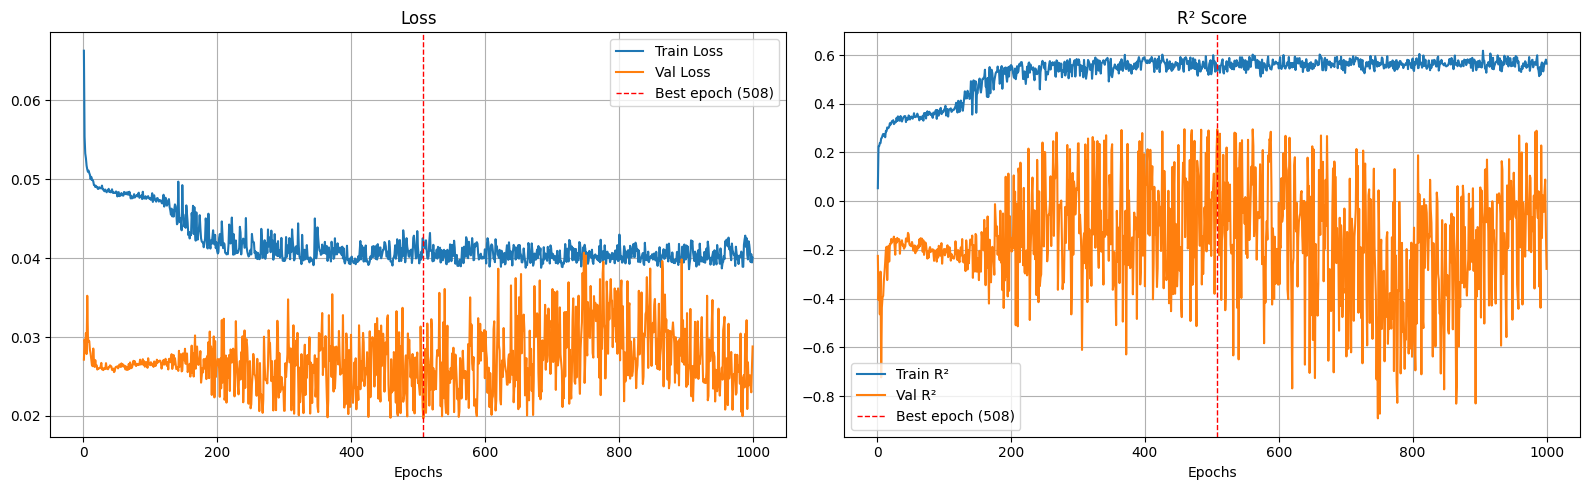

In [7]:
best_epoch = np.argmin(history.history['val_loss']) + 1
epochs = range(1, len(history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(epochs, history.history['loss'], label='Train Loss')
ax1.plot(epochs, history.history['val_loss'], label='Val Loss')
ax1.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.legend()
ax1.grid()

ax2.plot(epochs, history.history['r2_score'], label='Train R²')
ax2.plot(epochs, history.history['val_r2_score'], label='Val R²')
ax2.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax2.set_title('R² Score')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

In [10]:
# Test evaluation
model.load_weights('best_model.weights.h5')
loss, r2, mae, rmse = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss: {loss:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Test Loss: 0.0275, R²: 0.5074, MAE: 0.0275, RMSE: 0.0426


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


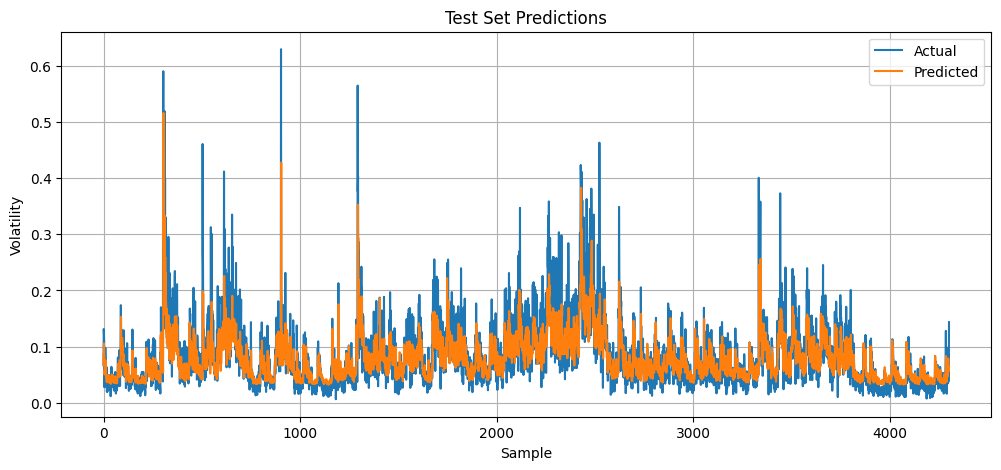

In [9]:
# Predictions plot
preds = model.predict(test_X).flatten()

plt.figure(figsize=(12, 5))
plt.plot(test_Y, label='Actual')
plt.plot(preds, label='Predicted')
plt.title('Test Set Predictions')
plt.xlabel('Sample')
plt.ylabel('Volatility')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from pathlib import Path
import statsmodels.api as sm
from scipy.stats import norm

def diebold_mariano(y, f1, f2, h=1, power=2, alternative="two-sided"):
    y = np.asarray(y, dtype=float)
    f1 = np.asarray(f1, dtype=float)
    f2 = np.asarray(f2, dtype=float)
    if y.shape != f1.shape or y.shape != f2.shape:
        raise ValueError("y, f1, and f2 must have the same shape")
    mask = np.isfinite(y) & np.isfinite(f1) & np.isfinite(f2)
    y = y[mask]
    f1 = f1[mask]
    f2 = f2[mask]
    e1 = y - f1
    e2 = y - f2
    if power == 1:
        d = np.abs(e1) - np.abs(e2)
    else:
        d = np.abs(e1) ** power - np.abs(e2) ** power
    dbar = d.mean()
    lag = max(0, h - 1)
    def newey_west_variance(x, lags):
        acov = sm.tsa.stattools.acovf(x, unbiased=True, fft=False, nlag=lags)
        var = acov[0]
        for k in range(1, lags + 1):
            var += 2 * (1 - k / (lags + 1)) * acov[k]
        return var / len(x)
    var = newey_west_variance(d, lag)
    dm_stat = dbar / np.sqrt(var)
    if alternative == "two-sided":
        pval = 2 * (1 - norm.cdf(abs(dm_stat)))
    elif alternative == "less":
        pval = norm.cdf(dm_stat)
    else:
        pval = 1 - norm.cdf(dm_stat)
    return dm_stat, pval, dbar, var

forecast_path = Path(r"C:\Users\Franswa\Documents\TickStream\Option data dash\note\test_forecasts.npz")
with np.load(forecast_path) as data:
    f_new = data["new"]
    y_new = data["actual"]

if y_new.shape != test_Y.shape:
    raise ValueError("Saved test forecast actuals do not match DNN_OHLC test set shape.")
if not np.allclose(test_Y, y_new, atol=1e-8):
    print("Warning: actual values differ slightly; using DNN_OHLC test_Y for the DM comparison.")
y = test_Y
f_baseline = preds

dm_stat, pval, dbar, var = diebold_mariano(y, f_baseline, f_new, h=1, power=2, alternative="two-sided")
print("Diebold-Mariano result:")
print(f" DM stat: {dm_stat:.4f}")
print(f" p-value: {pval:.4f}")
print(f" mean loss difference (baseline - new): {dbar:.6f}")
print("Interpretation: if DM stat > 0 and p-value < 0.05, the new model is significantly better.")


In [ ]:
# Retrain the DNN on each processed set and print a compact metrics summary
import os, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

DROP_COLS = [
    'prev_5m_log_return_1', 'prev_5m_log_return_2', 'prev_5m_log_return_3', 'prev_5m_log_return_4',
    'prev_day_log_return', 'day_of_week', 'day_of_month', 'prev_5m_high_low_range',
    'prev_atm_iv_30dte', 'prev_atm_iv_0dte', 'prev_total_option_volume', 'prev_total_option_oi'
]

MODEL_PARAMS = {
    'learning_rate': 0.0005,
    'dropout': 0.2,
    'gru_units_1': 64,
    'gru_units_2': 64,
    'dense_units': 32,
}

def find_project_root(marker_dir='34_features_newvol'):
    p = os.getcwd()
    while True:
        if os.path.isdir(os.path.join(p, marker_dir)):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            raise FileNotFoundError(f"Could not find '{marker_dir}' in any parent of cwd={os.getcwd()}")
        p = parent

ROOT = find_project_root()
OUTDIR = os.path.join(ROOT, '34_features_newvol', 'processed_sets')
SUMMARY = os.path.join(OUTDIR, 'summary.json')
with open(SUMMARY, 'r') as f:
    summary = json.load(f)

datasets = {
    #'original': os.path.join(ROOT, '34_features_newvol', 'train_features_5m_clean.parquet'),
    'removed_peak_month': os.path.join(OUTDIR, os.path.basename(summary['removed_peak_month']['path'])),
    'winsorized_1_99': os.path.join(OUTDIR, os.path.basename(summary['winsorized_1_99']['path'])),
    'regime_high_vol': os.path.join(OUTDIR, os.path.basename(summary['regime_high_vol']['path'])),
    'regime_low_vol': os.path.join(OUTDIR, os.path.basename(summary['regime_low_vol']['path'])),
}

def build_dnn_model():
    inp = keras.Input(shape=(5, 4))
    x = keras.layers.GRU(MODEL_PARAMS['gru_units_1'], return_sequences=True)(inp)
    x = keras.layers.Dropout(MODEL_PARAMS['dropout'])(x)
    x = keras.layers.GRU(MODEL_PARAMS['gru_units_2'])(x)
    x = keras.layers.Dropout(MODEL_PARAMS['dropout'])(x)
    x = keras.layers.Dense(MODEL_PARAMS['dense_units'], activation='relu')(x)
    x = keras.layers.Dropout(MODEL_PARAMS['dropout'])(x)
    out = keras.layers.Dense(1, activation='linear', name='output')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=MODEL_PARAMS['learning_rate']),
        loss='mean_absolute_error',
        metrics=[keras.metrics.R2Score(), 'mae', keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

rows = []
for name, path in datasets.items():
    print(f"\n=== Dataset: {name} — loading {path}")
    df = pd.read_parquet(path)

    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    df['bar5'] = pd.to_datetime(df['bar5'], errors='coerce')
    df = df.dropna(subset=['bar5', 'target_ann_vol'])

    train_df = df[df['bar5'].dt.date < pd.Timestamp('2025-10-03').date()].copy()
    test_df  = df[df['bar5'].dt.date >= pd.Timestamp('2025-10-06').date()].copy()

    n_train, n_test = len(train_df), len(test_df)

    X_train = train_df.iloc[:, 1:-1].to_numpy(dtype=float)
    X_test  = test_df.iloc[:, 1:-1].to_numpy(dtype=float)
    y_train = train_df['target_ann_vol'].to_numpy(dtype=float)
    y_test  = test_df['target_ann_vol'].to_numpy(dtype=float)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = X_train.reshape(-1, 5, 4).astype('float32')
    X_test = X_test.reshape(-1, 5, 4).astype('float32')

    model = build_dnn_model()
    best_model_path = f"best_model_{name}.weights.h5"
    best_model_callback = keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
    history = model.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=512,
        validation_split=0.2,
        callbacks=[best_model_callback],
        verbose=0,
    )

    model.load_weights(best_model_path)

    loss, r2, mae, rmse = model.evaluate(X_test, y_test, verbose=0)
    rows.append({
        'dataset': name,
        'n_train': n_train,
        'n_test': n_test,
        'test_loss': float(loss),
        'test_R2': float(r2),
        'test_MAE': float(mae),
        'test_RMSE': float(rmse),
        'epochs': len(history.history['loss']),
    })
    print(f" test: R2={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, epochs={len(history.history['loss'])}")

summary_df = pd.DataFrame(rows).set_index('dataset')
print('\n==== DNN retrain summary ===')
print(summary_df)



=== Dataset: removed_peak_month — loading c:\Users\Franswa\Documents\TickStream\Option data dash\34_features_newvol\processed_sets\removed_peak_month.parquet
 test: R2=0.5168, MAE=0.0277, RMSE=0.0422, epochs=1000

=== Dataset: winsorized_1_99 — loading c:\Users\Franswa\Documents\TickStream\Option data dash\34_features_newvol\processed_sets\winsorized_1_99.parquet
 test: R2=0.4952, MAE=0.0274, RMSE=0.0426, epochs=1000

=== Dataset: regime_high_vol — loading c:\Users\Franswa\Documents\TickStream\Option data dash\34_features_newvol\processed_sets\regime_high_vol.parquet


KeyboardInterrupt: 